<a href="https://colab.research.google.com/github/Madhav-Sharma91/RFL-python-internship/blob/main/day24_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DUPLICATE TRANSACTIONS: 4
HIGH-VALUE TRANSACTIONS: 88
SUSPICIOUS ACCOUNTS: ['ACC104', 'ACC103', 'ACC101', 'ACC102', 'ACC105', 'ACC100', 'ACC107', 'ACC106']

TOP 10 TRANSACTIONS
     Transaction_ID Account_ID  Amount
135          T0136     ACC105   99874
145          T0146     ACC101   99758
45           T0046     ACC100   98555
2            T0003     ACC101   98478
27           T0028     ACC102   98459
49           T0050     ACC102   97793
50           T0050     ACC102   97793
32           T0033     ACC102   97038
25           T0026     ACC107   96984
42           T0043     ACC107   96329


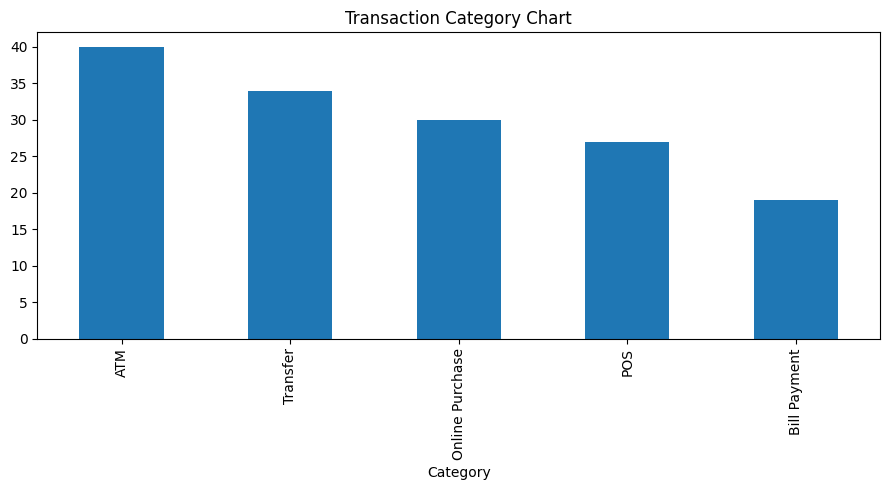

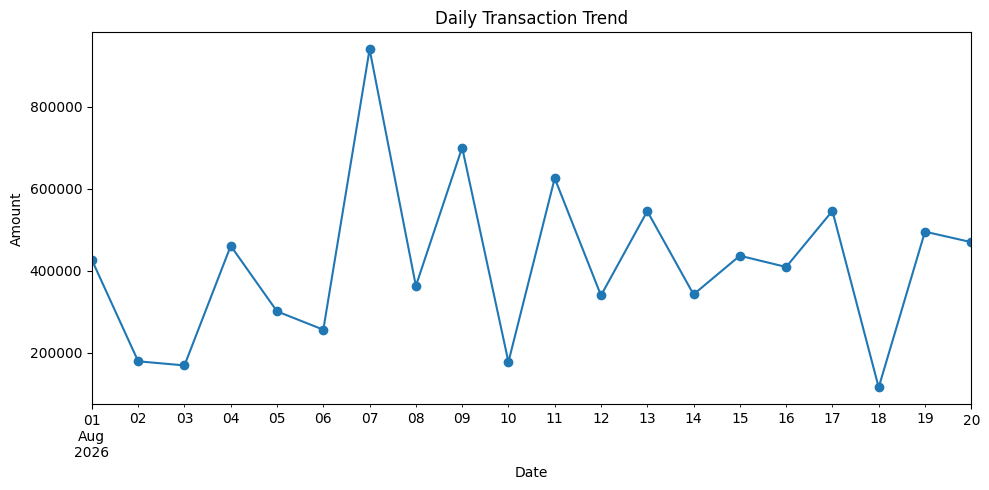

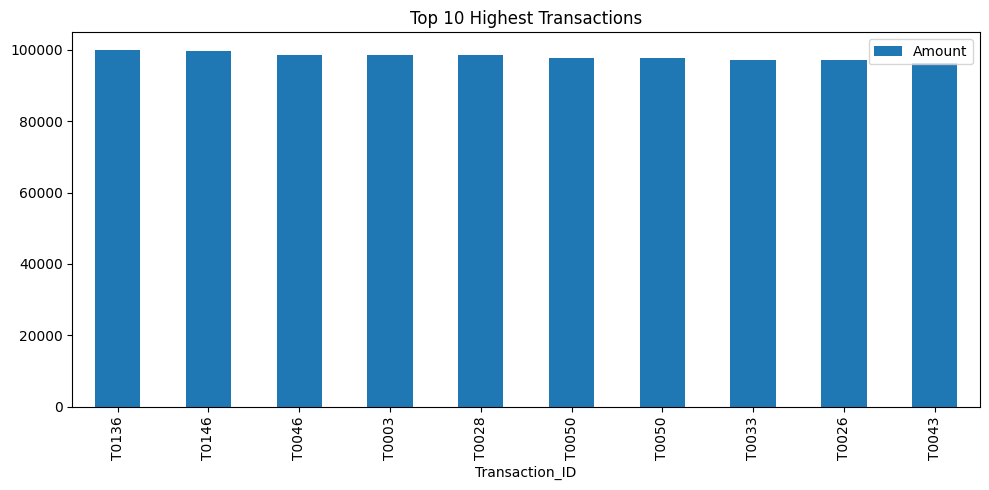

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

THRESHOLD = 50000
FREQUENT = 5

df = pd.read_csv("transactions.csv").dropna()
df["Date"] = pd.to_datetime(df["Date"])
df["Amount"] = pd.to_numeric(df["Amount"])

duplicates = df[df.duplicated(["Account_ID","Date","Amount","Category"], keep=False)]
high = df[df["Amount"] > THRESHOLD]
counts = df["Account_ID"].value_counts()
suspicious_accounts = counts[counts >= FREQUENT].index

def risk(row):
    score = 0
    if row["Amount"] > THRESHOLD: score += 50
    if row["Account_ID"] in suspicious_accounts: score += 30
    return score

df["Risk_Score"] = df.apply(risk, axis=1)
suspicious = df[(df["Risk_Score"] >= 30) | df.duplicated(["Account_ID","Date","Amount","Category"],keep=False)]

print("DUPLICATE TRANSACTIONS:", len(duplicates))
print("HIGH-VALUE TRANSACTIONS:", len(high))
print("SUSPICIOUS ACCOUNTS:", list(suspicious_accounts))
print("\nTOP 10 TRANSACTIONS\n", df.nlargest(10,"Amount")[["Transaction_ID","Account_ID","Amount"]])

df["Category"].value_counts().plot(kind="bar", figsize=(9,5), title="Transaction Category Chart")
plt.tight_layout(); plt.savefig("transaction_category_chart.png"); plt.show()

df.groupby("Date")["Amount"].sum().plot(figsize=(10,5), marker="o", title="Daily Transaction Trend")
plt.ylabel("Amount"); plt.tight_layout(); plt.savefig("daily_transaction_trend.png"); plt.show()

df.nlargest(10,"Amount").plot(x="Transaction_ID",y="Amount",kind="bar",figsize=(10,5),title="Top 10 Highest Transactions")
plt.tight_layout(); plt.savefig("top_10_highest_transactions.png"); plt.show()

suspicious.to_csv("suspicious_transactions.csv",index=False)
